# Лабораторная работа #4
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

## Задание 1. Апроксимация функции двух переменных методом Гауссианы

### 1.1. Входные данные

In [9]:
# ==============================================================================
# ЗАДАНИЕ 1: Аппроксимация Гауссианой с кривой обучения
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

# Данные
data = np.array([
    [0.89, 0.97, 0.41],
    [2.04, 1.83, 1.79],
    [2.82, 3.05, 4.28],
    [3.84, 3.85, 2.54],
    [4.97, 4.85, 0.50]
])

X = data[:, 0]
Y = data[:, 1]
Z = data[:, 2]

### 1.2. Функция Гаусса

In [10]:
def gauss_2d(x, y, A, x0, y0, sigma_x, sigma_y, theta=0, offset=0):
    if theta != 0:
        x_new = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
        y_new = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    else:
        x_new = x - x0
        y_new = y - y0

    exp_part = np.exp(-(x_new ** 2 / (2 * sigma_x ** 2) + y_new ** 2 / (2 * sigma_y ** 2)))

    return A * exp_part + offset

### 1.3. Функция потерь с историей изменений

In [11]:
loss_history_gaussian = []
def loss_function_gaussian(params):
    A, x0, y0, sigma_x, sigma_y, theta, offset = params

    if sigma_x <= 0 or sigma_y <= 0 or A <= 0:
        return 1e10

    predictions = gauss_2d(X, Y, A, x0, y0, sigma_x, sigma_y, theta, offset)
    mse = 0.5 * np.mean((Z - predictions) ** 2)

    if not loss_history_gaussian or mse < loss_history_gaussian[-1]:
        loss_history_gaussian.append(mse)

    return mse

### 1.4. Вычисления

In [12]:
# Начальное приближение
max_idx = np.argmax(Z)
A_start = Z[max_idx] + 0.1
x0_start = X[max_idx]
y0_start = Y[max_idx]
sigma_x_start = np.std(X) * 0.5
sigma_y_start = np.std(Y) * 0.5
offset_start = 0.0
theta_start = 0.0

params_start = [A_start, x0_start, y0_start, sigma_x_start, sigma_y_start, theta_start, offset_start]

bounds = [
    (0.1, 10.0), (0.0, 6.0), (0.0, 6.0),
    (0.1, 5.0), (0.1, 5.0), (-np.pi / 4, np.pi / 4), (-1.0, 1.0)
]

print("\n" + "="*60)
print("ЗАДАНИЕ 1: Аппроксимация Гауссианой")
print("="*60)

# Запускаем оптимизацию
result = minimize(loss_function_gaussian, params_start, method='L-BFGS-B', bounds=bounds)

A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt = result.x

print("\nРЕЗУЛЬТАТЫ:")
print(f"A = {A_opt:.4f}")
print(f"x0 = {x0_opt:.4f}, y0 = {y0_opt:.4f}")
print(f"sigma_x = {sigma_x_opt:.4f}, sigma_y = {sigma_y_opt:.4f}")
print(f"theta = {theta_opt:.4f} рад = {np.degrees(theta_opt):.2f}°, offset = {offset_opt:.4f}")
print(f"Финальная MSE: {result.fun:.10f}")

# Предсказания и невязки
predictions_gaussian = gauss_2d(X, Y, A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt)
residuals_gaussian = Z - predictions_gaussian


print("\n" + "="*60)
df_gaussian_results = pd.DataFrame({
    '№ точки': range(len(X)),
    'Реальное Z': Z,
    'Предсказание': predictions_gaussian,
    'Невязка': residuals_gaussian,
    '|Невязка|': np.abs(residuals_gaussian)
})

# Выводим таблицу с форматированием
print(df_gaussian_results.to_string(
    index=False,
    formatters={
        'Реальное Z': '{:.5f}'.format,
        'Предсказание': '{:.8f}'.format,
        'Невязка': '{:.10e}'.format,
        '|Невязка|': '{:.10e}'.format
    }
))


ЗАДАНИЕ 1: Аппроксимация Гауссианой

РЕЗУЛЬТАТЫ:
A = 4.0144
x0 = 2.9798, y0 = 3.0440
sigma_x = 1.0896, sigma_y = 1.0860
theta = -0.0096 рад = -0.55°, offset = 0.3085
Финальная MSE: 0.0000004805

 № точки Реальное Z Предсказание           Невязка        |Невязка|
       0    0.41000   0.41145112 -1.4511189011e-03 1.4511189011e-03
       1    1.79000   1.78991181  8.8188343735e-05 8.8188343735e-05
       2    4.28000   4.27985337  1.4663497769e-04 1.4663497769e-04
       3    2.54000   2.54037294 -3.7293663071e-04 3.7293663071e-04
       4    0.50000   0.49840912  1.5908778151e-03 1.5908778151e-03


### 1.5. Визуализация

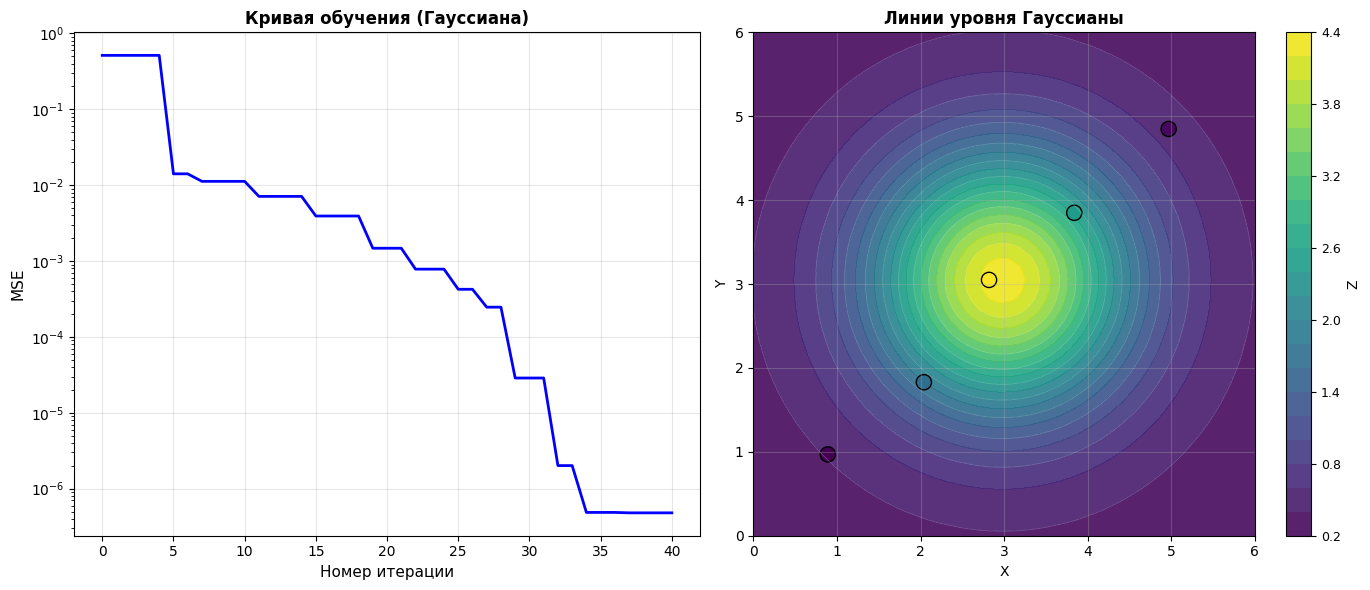


Количество итераций: 41


In [13]:
# Визуализация
fig = plt.figure(figsize=(14, 6))

# 1. Кривая обучения
ax1 = fig.add_subplot(121)
ax1.plot(loss_history_gaussian, 'b-', linewidth=2)
ax1.set_xlabel('Номер итерации', fontsize=11)
ax1.set_ylabel('MSE', fontsize=11)
ax1.set_title('Кривая обучения (Гауссиана)', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. Линии уровня
ax2 = fig.add_subplot(122)
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_grid = np.zeros((50, 50))
for i in range(50):
    for j in range(50):
        Z_grid[i, j] = gauss_2d(X_grid[i, j], Y_grid[i, j], A_opt, x0_opt, y0_opt, sigma_x_opt, sigma_y_opt, theta_opt, offset_opt)

contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.9)
ax2.scatter(X, Y, c=Z, s=120, edgecolors='black', cmap='viridis')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_title('Линии уровня Гауссианы', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(contour, ax=ax2, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print(f"\nКоличество итераций: {len(loss_history_gaussian)}")

---

## Задание 2. Апроксимация функции двух переменных методом эллиптического парабалоида

### 2.1. Функция 2D эллиптического парабалоида

In [14]:
history_par = []
def paraboloid_2d(x, y, a, b, x0, y0, c):
    """
    2D эллиптический параболоид
    Формула: z = a*(x-x0)² + b*(y-y0)² + c
    """
    return a * (x - x0)**2 + b * (y - y0)**2 + c

### 2.2. Функция потери

In [15]:
def loss_function_paraboloid(params):
    a, b, x0, y0, c = params
    if a >= 0 or b >= 0:
        return 1e10

    _predictions = paraboloid_2d(X, Y, a, b, x0, y0, c)
    _mse = np.mean((Z - _predictions)**2)

    if not history_par or _mse < history_par[-1]:
        history_par.append(_mse)

    return _mse

### 2.3. Вычисления

In [16]:
# Начальное приближение
max_idx = np.argmax(Z)
a_start = -0.3
b_start = -0.3
x0_start = X[max_idx]
y0_start = Y[max_idx]
c_start = Z[max_idx]

params_start_par = [a_start, b_start, x0_start, y0_start, c_start]

print(f"\nНачальное приближение для параболоида:")
print(f"  a = {a_start:.2f}, b = {b_start:.2f}")
print(f"  x0 = {x0_start:.2f}, y0 = {y0_start:.2f}")
print(f"  c = {c_start:.2f}")

# Границы для параметров
bounds_par = [
    (-2.0, -0.01),   # a
    (-2.0, -0.01),   # b
    (0.0, 6.0),      # x0
    (0.0, 6.0),      # y0
    (-1.0, 5.0)      # c
]

print("\nЗапускаем оптимизацию для параболоида...")
result_par = minimize(loss_function_paraboloid, params_start_par, method='L-BFGS-B', bounds=bounds_par)

# Получение результатов
a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt = result_par.x

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ ПАРАБОЛОИДОМ")
print("="*60)
print(f"\na = {a_opt:.6f}")
print(f"b = {b_opt:.6f}")
print(f"x0 = {x0_opt_par:.4f}, y0 = {y0_opt_par:.4f}")
print(f"c = {c_opt:.6f}")
print(f"\nФинальная MSE: {result_par.fun:.8f}")

# Предсказания и невязки
predictions_par = paraboloid_2d(X, Y, a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt)
residuals_par = Z - predictions_par

# Кривая обучения (loss-функция)
result_with_history = minimize(loss_function_paraboloid, params_start_par, method='L-BFGS-B',
                                bounds=bounds_par, options={'maxiter': 100})

print(f"\nКоличество итераций оптимизации: {len(history_par)}")


Начальное приближение для параболоида:
  a = -0.30, b = -0.30
  x0 = 2.82, y0 = 3.05
  c = 4.28

Запускаем оптимизацию для параболоида...

РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ ПАРАБОЛОИДОМ

a = -0.233431
b = -0.556918
x0 = 0.8041, y0 = 3.8958
c = 5.000000

Финальная MSE: 0.15008804

Количество итераций оптимизации: 96


### 2.4. Таблица невязок

In [17]:
import pandas as pd

print("\n" + "-"*40)
print("Таблица невязок:")
print("-"*40)

df_results = pd.DataFrame({
    '№ точки': range(len(X)),
    'Реальное Z': Z,
    'Предсказание': predictions_par,
    'Невязка': residuals_par
})
print(df_results.to_string(index=False))
print("\n" + "-"*40)


----------------------------------------
Таблица невязок:
----------------------------------------
 № точки  Реальное Z  Предсказание   Невязка
       0        0.41      0.230858  0.179142
       1        1.79      2.266741 -0.476741
       2        4.28      3.652924  0.627076
       3        2.54      2.847323 -0.307323
       4        0.50      0.441744  0.058256

----------------------------------------


### 2.5. Визуализация

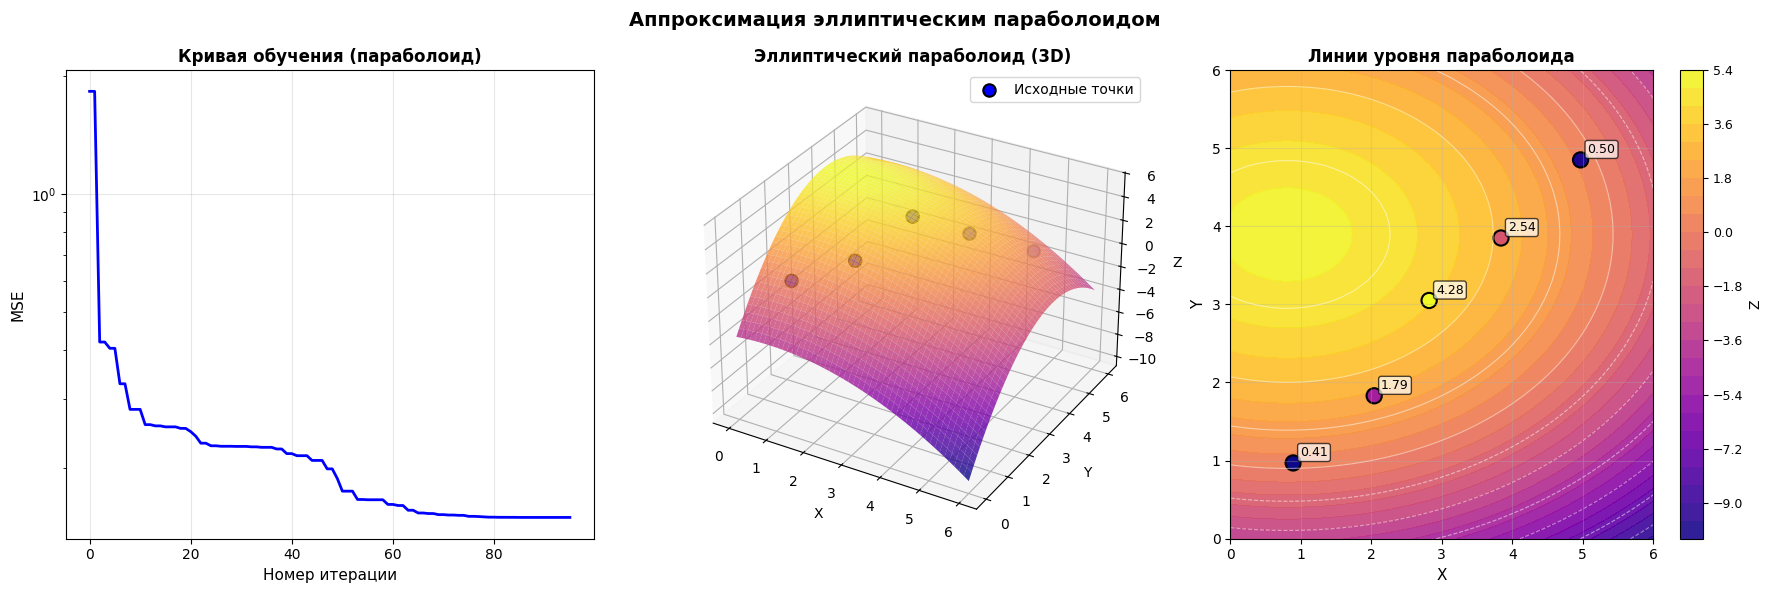


Аналитический вид полученной модели (параболоид):
z(x,y) = (-0.233431)·(x - 0.8041)² + (-0.556918)·(y - 3.8958)² + 5.000000

где a и b отрицательные, поэтому параболоид имеет форму 'шапки' (максимум в центре)


In [18]:
# Создаем сетку для визуализации поверхности
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z_grid_par = paraboloid_2d(X_grid, Y_grid, a_opt, b_opt, x0_opt_par, y0_opt_par, c_opt)

# Создаем фигуру с 3 подграфиками (вместо 4)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Кривая обучения
ax1 = axes[0]
ax1.plot(history_par, 'b-', linewidth=2)
ax1.set_xlabel('Номер итерации', fontsize=11)
ax1.set_ylabel('MSE', fontsize=11)
ax1.set_title('Кривая обучения (параболоид)', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. 3D поверхность параболоида
fig.delaxes(axes[1])
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

surf = ax2.plot_surface(X_grid, Y_grid, Z_grid_par, cmap='plasma', alpha=0.8, edgecolor='none')
ax2.scatter(X, Y, Z, c='blue', s=80, edgecolors='black', linewidth=1.5, label='Исходные точки')
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_zlabel('Z', fontsize=10)
ax2.set_title('Эллиптический параболоид (3D)', fontsize=12, fontweight='bold')
ax2.legend()

# 3. Линии уровня
ax3 = axes[2]
contour = ax3.contourf(X_grid, Y_grid, Z_grid_par, levels=25, cmap='plasma', alpha=0.9)
ax3.scatter(X, Y, c=Z, s=120, edgecolors='black', linewidth=1.5, cmap='plasma')
ax3.contour(X_grid, Y_grid, Z_grid_par, levels=10, colors='white', alpha=0.5, linewidths=0.8)

# Добавляем подписи значений Z
for i, (x, y, z) in enumerate(zip(X, Y, Z)):
    ax3.annotate(f'{z:.2f}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax3.set_xlabel('X', fontsize=11)
ax3.set_ylabel('Y', fontsize=11)
ax3.set_title('Линии уровня параболоида', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

cbar = plt.colorbar(contour, ax=ax3, label='Z')
cbar.ax.tick_params(labelsize=9)

plt.suptitle('Аппроксимация эллиптическим параболоидом', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Аналитический вид полученной модели (параболоид):")
print("="*60)
print(f"z(x,y) = ({a_opt:.6f})·(x - {x0_opt_par:.4f})² + ({b_opt:.6f})·(y - {y0_opt_par:.4f})² + {c_opt:.6f}")
print("\nгде a и b отрицательные, поэтому параболоид имеет форму 'шапки' (максимум в центре)")

---

## Задание 3. Нахождение наилучшей апроксимации

### 3.1. Минимизация MSE (Mean Square Error)

In [19]:
# Исходные данные
print("\nИсходные данные (Z):")
for i, z in enumerate(Z):
    print(f"  Точка {i}: z = {z:.2f}")


Исходные данные (Z):
  Точка 0: z = 0.41
  Точка 1: z = 1.79
  Точка 2: z = 4.28
  Точка 3: z = 2.54
  Точка 4: z = 0.50


In [20]:
const_mse = np.mean(Z)
predictions_mse = np.full_like(Z, const_mse)
residuals_mse = Z - const_mse
mse_value = np.mean(residuals_mse**2)

### 3.2. Минимизация MAE (Mean Absolute Error)

In [21]:
const_mae = np.median(Z)
predictions_mae = np.full_like(Z, const_mae)
residuals_mae = Z - const_mae
mae_value = np.mean(np.abs(residuals_mae))
mse_of_mae_model = np.mean(residuals_mae**2)

### 3.3. Таблица невязок

In [22]:
# 3.3. Исправленная таблица невязок с понятными названиями
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА НЕВЯЗОК (константные модели)")
print("="*60)

df_summary = pd.DataFrame({
    '№ точки': range(len(Z)),
    'Исходное Z': Z,
    'MSE модель (предск.)': predictions_mse.round(4),
    'MSE модель (невязка)': residuals_mse.round(4),
    'MAE модель (предск.)': predictions_mae.round(4),
    'MAE модель (невязка)': residuals_mae.round(4)
})
print(df_summary.to_string(index=False))

# Дополнительная проверка
print("\n" + "-"*40)
print(f"MSE модель использует константу = среднее = {const_mse:.4f}")
print(f"MAE модель использует константу = медиана = {const_mae:.4f}")
print("-"*40)


СВОДНАЯ ТАБЛИЦА НЕВЯЗОК (константные модели)
 № точки  Исходное Z  MSE модель (предск.)  MSE модель (невязка)  MAE модель (предск.)  MAE модель (невязка)
       0        0.41                 1.904                -1.494                  1.79                 -1.38
       1        1.79                 1.904                -0.114                  1.79                  0.00
       2        4.28                 1.904                 2.376                  1.79                  2.49
       3        2.54                 1.904                 0.636                  1.79                  0.75
       4        0.50                 1.904                -1.404                  1.79                 -1.29

----------------------------------------
MSE модель использует константу = среднее = 1.9040
MAE модель использует константу = медиана = 1.7900
----------------------------------------


### 3.4. Сравнение моделей

In [23]:
print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

comparison_data = {
    'Модель': ['MSE модель (среднее)', 'MAE модель (медиана)'],
    'Константа (c)': [f'{const_mse:.4f}', f'{const_mae:.4f}'],
    'MSE': [f'{mse_value:.6f}', f'{mse_of_mae_model:.6f}'],
    'MAE': [f'{np.mean(np.abs(residuals_mse)):.6f}', f'{mae_value:.6f}']
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)

if mse_value < mse_of_mae_model:
    print(f"  ✅ По критерию MSE лучше модель с константой = среднему ({const_mse:.4f})")
else:
    print(f"  ✅ По критерию MSE лучше модель с константой = медиане ({const_mae:.4f})")

if mae_value < np.mean(np.abs(residuals_mse)):
    print(f"  ✅ По критерию MAE лучше модель с константой = медиане ({const_mae:.4f})")
else:
    print(f"  ✅ По критерию MAE лучше модель с константой = среднему ({const_mse:.4f})")


СРАВНЕНИЕ МОДЕЛЕЙ
              Модель Константа (c)      MSE      MAE
MSE модель (среднее)        1.9040 2.053224 1.204800
MAE модель (медиана)        1.7900 2.066220 1.182000

ВЫВОДЫ
  ✅ По критерию MSE лучше модель с константой = среднему (1.9040)
  ✅ По критерию MAE лучше модель с константой = медиане (1.7900)


## Задание 5. Апроксимация функции RBF-сетью

### 5.1. Исходные данные и модель

In [24]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
    [0.89, 0.97, 0.41],
    [2.04, 1.83, 1.79],
    [2.82, 3.05, 4.28],
    [3.84, 3.85, 2.54],
    [4.97, 4.85, 0.50]
])

X = data[:, 0]
Y = data[:, 1]
Z = data[:, 2]

# ==============================================================================
# РЕАЛИЗАЦИЯ RBF-СЕТИ
# ==============================================================================

class SimpleRBF:
    """Простая RBF-сеть для аппроксимации функции двух переменных"""

    def __init__(self, sigma=1.0):
        """
        sigma - ширина радиальной функции (параметр сглаживания)
        """
        self.sigma = sigma
        self.centers = None      # Центры RBF
        self.weights = None      # Веса
        self.bias = None         # Смещение
        self.loss_history = []   # История ошибок

    def _rbf(self, x, y, center):
        """
        Гауссовская радиальная базисная функция
        φ(r) = exp(-r² / (2σ²))
        """
        r2 = (x - center[0])**2 + (y - center[1])**2
        return np.exp(-r2 / (2 * self.sigma**2))

    def _build_matrix(self, X, Y):
        """
        Строит матрицу Φ размера N x M
        Φ[i,j] = φ(||x_i - c_j||)
        """
        N = len(X)
        M = len(self.centers)
        Phi = np.zeros((N, M))

        for i in range(N):
            for j in range(M):
                Phi[i, j] = self._rbf(X[i], Y[i], self.centers[j])

        return Phi

    def fit(self, X, Y, Z, learning_rate=0.05, epochs=2000, verbose=True):
        """
        Обучение RBF-сети методом градиентного спуска
        Стратегия 2: центры = все точки данных
        """
        # Устанавливаем центры в каждой точке данных
        self.centers = np.column_stack((X, Y))
        M = len(self.centers)
        N = len(X)

        # Строим матрицу Φ (один раз, так как центры фиксированы)
        Phi = self._build_matrix(X, Y)

        # Инициализируем веса нулями
        self.weights = np.zeros(M)
        self.bias = 0.0

        # Очищаем историю ошибок
        self.loss_history = []

        # Градиентный спуск
        for epoch in range(epochs):
            # Предсказание
            predictions = Phi @ self.weights + self.bias

            # Ошибка
            error = Z - predictions

            # MSE Loss
            loss = np.mean(error**2)
            self.loss_history.append(loss)

            # Градиенты
            grad_w = -2/N * Phi.T @ error
            grad_b = -2/N * np.sum(error)

            # Обновление весов
            self.weights -= learning_rate * grad_w
            self.bias -= learning_rate * grad_b

        return self

    def predict(self, X, Y):
        """Предсказание для новых точек"""
        Phi = self._build_matrix(X, Y)
        return Phi @ self.weights + self.bias

### 5.2. Обучение модели

In [25]:
# Параметры
sigma_list = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
learning_rate = 0.05
epochs = 250

results = {}
best_mse = float('inf')
best_sigma = None

for sigma in sigma_list:
    # Создаём и обучаем сеть
    rbf = SimpleRBF(sigma=sigma)
    rbf.fit(X, Y, Z, learning_rate=learning_rate, epochs=epochs, verbose=True)

    # Предсказания
    pred = rbf.predict(X, Y)
    mse = np.mean((Z - pred)**2)

    results[sigma] = {
        'model': rbf,
        'mse': mse,
        'predictions': pred,
        'residuals': Z - pred,
        'history': rbf.loss_history
    }

    if mse < best_mse:
        best_mse = mse
        best_sigma = sigma

best_model = results[best_sigma]['model']
best_pred = results[best_sigma]['predictions']
best_residuals = results[best_sigma]['residuals']
best_history = results[best_sigma]['history']


### 5.3. Визуализация.
#### 5.3.1. Кривая обучения

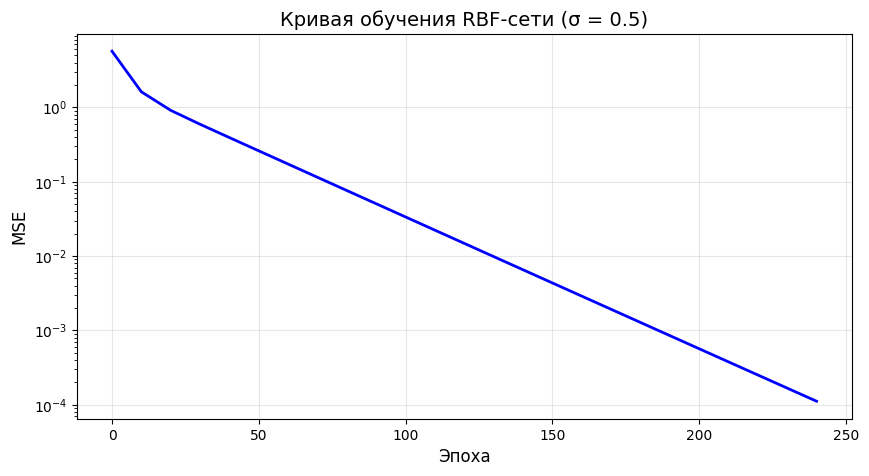

In [26]:
plt.close('all')

# Функция для прореживания данных
def downsample(data, factor=10):
    """Прореживание данных для уменьшения количества точек на графике"""
    return data[::factor]

# --- ГРАФИК 1: Кривая обучения ---
plt.figure(figsize=(10, 5))
# Прореживаем для читаемости
downsampled_epochs = np.arange(0, len(best_history), 10)
downsampled_loss = [best_history[i] for i in downsampled_epochs]
plt.plot(downsampled_epochs, downsampled_loss, 'b-', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title(f'Кривая обучения RBF-сети (σ = {best_sigma})', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

#### 5.3.2. Сравнение разных sigma

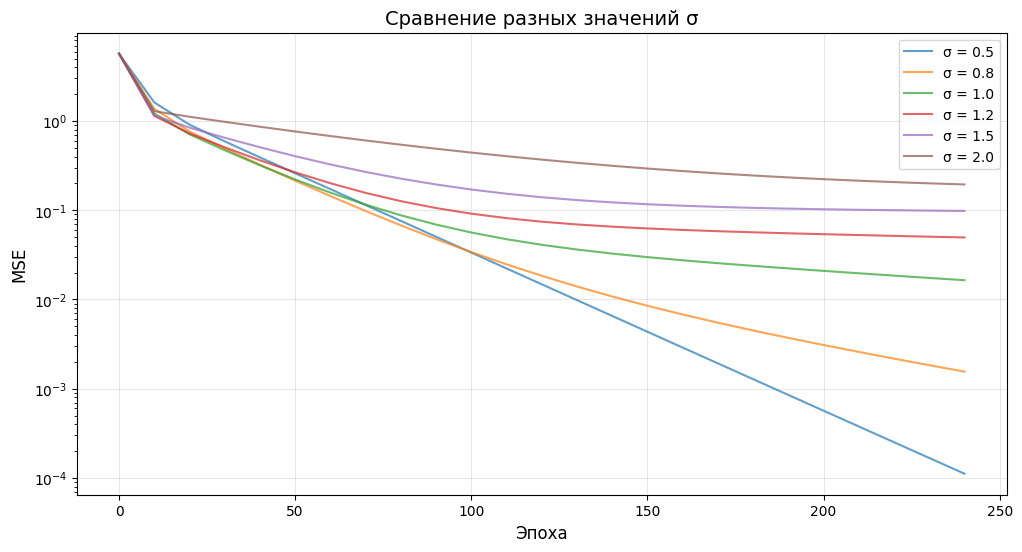

In [27]:
# --- ГРАФИК 2: Сравнение разных sigma ---
plt.figure(figsize=(12, 6))
for sigma, res in results.items():
    hist = res['history']
    downsampled = downsample(hist)
    epochs_short = np.arange(0, len(hist), 10)[:len(downsampled)]
    plt.plot(epochs_short, downsampled, label=f'σ = {sigma}', linewidth=1.5, alpha=0.7)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Сравнение разных значений σ', fontsize=14)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 5.3.3. Таблица невязок

In [28]:
# Формируем DataFrame с результатами
df_rbf_residuals = pd.DataFrame({
    '№ точки': range(len(Z)),
    'Реальное Z': Z,
    'Предсказание': best_pred,
    'Невязка': best_residuals,
    '|Невязка|': np.abs(best_residuals)
})

# Выводим таблицу с форматированием
print(df_rbf_residuals.to_string(
    index=False,
    formatters={
        'Реальное Z': '{:.4f}'.format,
        'Предсказание': '{:.8f}'.format,
        'Невязка': '{:.10e}'.format,
        '|Невязка|': '{:.10e}'.format
    }
))

 № точки Реальное Z Предсказание           Невязка        |Невязка|
       0     0.4100   0.41817656 -8.1765600526e-03 8.1765600526e-03
       1     1.7900   1.79038326 -3.8325731978e-04 3.8325731978e-04
       2     4.2800   4.26448472  1.5515276512e-02 1.5515276512e-02
       3     2.5400   2.53925679  7.4321082094e-04 7.4321082094e-04
       4     0.5000   0.50793617 -7.9361694360e-03 7.9361694360e-03


#### 5.3.4. График поверхности

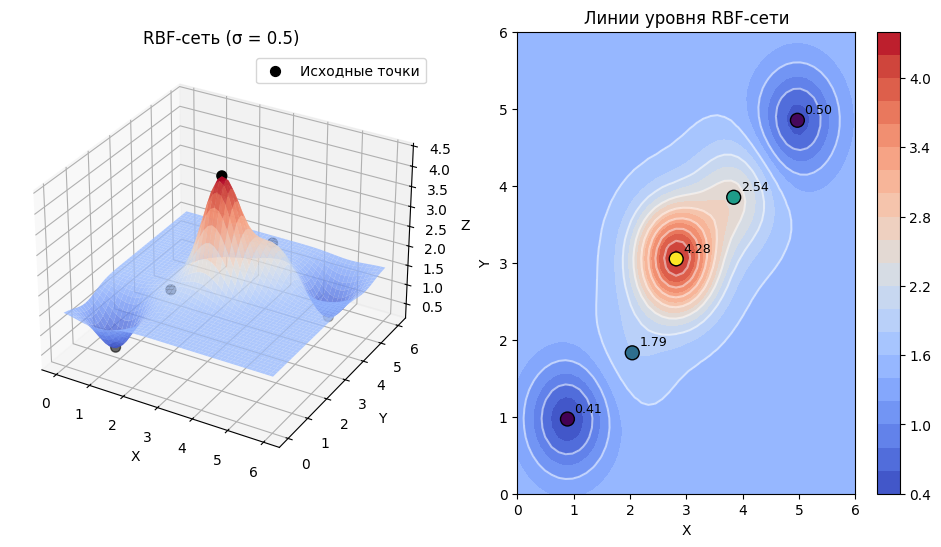

In [29]:
# Создаём сетку для визуализации
x_grid = np.linspace(0, 6, 50)
y_grid = np.linspace(0, 6, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Предсказания на сетке
Z_grid = np.zeros_like(X_grid)
for i in range(len(x_grid)):
    for j in range(len(y_grid)):
        Z_grid[j, i] = best_model.predict([X_grid[j, i]], [Y_grid[j, i]])[0]

fig = plt.figure(figsize=(12, 6))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='coolwarm', alpha=0.8)
ax1.scatter(X, Y, Z, c='black', s=50, label='Исходные точки')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'RBF-сеть (σ = {best_sigma})')
ax1.legend()

# Линии уровня
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=20, cmap='coolwarm')
ax2.scatter(X, Y, c=Z, s=100, edgecolors='black')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.5)
for i, (x, y, z) in enumerate(zip(X, Y, Z)):
    ax2.annotate(f'{z:.2f}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Линии уровня RBF-сети')
plt.colorbar(contour, ax=ax2)

plt.show()

#### 5.3.5. Сравнение всех моделей

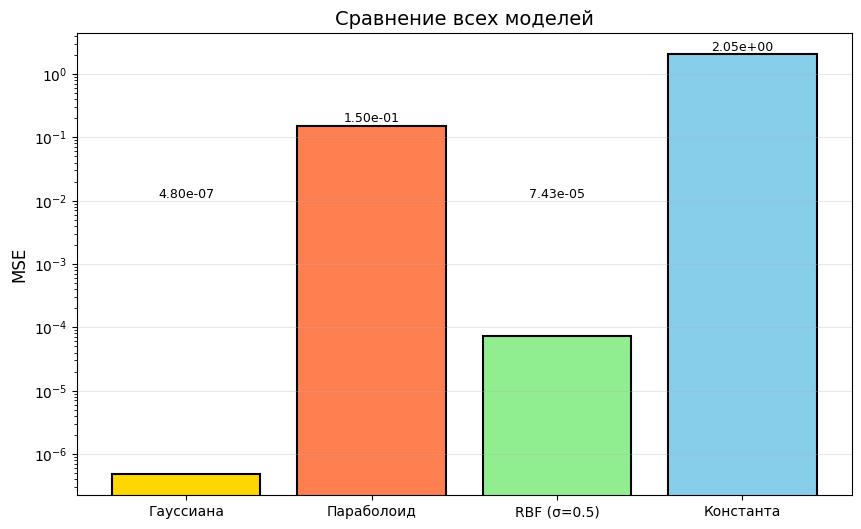

In [30]:
# --- ГРАФИК 5: Сравнение всех моделей ---
plt.figure(figsize=(10, 6))

# MSE других моделей
mse_gaussian = 0.00000048  # из задания 1
mse_paraboloid = 0.15008804  # из задания 2
mse_constant = np.mean((Z - np.mean(Z))**2)

models = ['Гауссиана', 'Параболоид', f'RBF (σ={best_sigma})', 'Константа']
mses = [mse_gaussian, mse_paraboloid, best_mse, mse_constant]
colors_comp = ['gold', 'coral', 'lightgreen', 'skyblue']

bars = plt.bar(models, mses, color=colors_comp, edgecolor='black', linewidth=1.5)
plt.ylabel('MSE', fontsize=12)
plt.title('Сравнение всех моделей', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

for bar, mse in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mse:.2e}', ha='center', va='bottom', fontsize=9)

plt.show()

### 5.4. Аналитический вид модели

In [31]:
print(f"\nf(x, y) = {best_model.bias:.6f}")

for i, (w, center) in enumerate(zip(best_model.weights, best_model.centers)):
    sign = "+" if w >= 0 else "-"
    print(f"         {sign} {abs(w):.6f}·exp(-((x-{center[0]:.2f})² + (y-{center[1]:.2f})²)/(2·{best_sigma}²))")


f(x, y) = 1.536433
         - 1.122001·exp(-((x-0.89)² + (y-0.97)²)/(2·0.5²))
         + 0.231463·exp(-((x-2.04)² + (y-1.83)²)/(2·0.5²))
         + 2.692617·exp(-((x-2.82)² + (y-3.05)²)/(2·0.5²))
         + 0.920299·exp(-((x-3.84)² + (y-3.85)²)/(2·0.5²))
         - 1.038185·exp(-((x-4.97)² + (y-4.85)²)/(2·0.5²))


### 5.5. Выводы

In [32]:
print(f"""
1. RBF-сеть успешно обучена методом градиентного спуска.
2. Лучшая ширина RBF: σ = {best_sigma}
3. Финальная MSE: {best_mse:.10e}
4. Финальная MAE: {np.mean(np.abs(best_residuals)):.10e}
5. RBF-сеть {'идеально' if best_mse < 1e-12 else 'хорошо'} аппроксимирует данные
6. При σ = {best_sigma} сеть {'точно интерполирует' if best_mse < 1e-12 else 'хорошо приближает'} все 5 точек.
7. Преимущества RBF:
   - Гибкость за счёт нескольких центров
   - Способность к точной интерполяции
   - Простота реализации
8. Недостатки:
   - Чувствительность к выбору σ
   - При малых σ может быть переобучение
   - При больших σ - сглаживание
""")


1. RBF-сеть успешно обучена методом градиентного спуска.
2. Лучшая ширина RBF: σ = 0.5
3. Финальная MSE: 7.4252394668e-05
4. Финальная MAE: 6.5508948282e-03
5. RBF-сеть хорошо аппроксимирует данные
6. При σ = 0.5 сеть хорошо приближает все 5 точек.
7. Преимущества RBF:
   - Гибкость за счёт нескольких центров
   - Способность к точной интерполяции
   - Простота реализации
8. Недостатки:
   - Чувствительность к выбору σ
   - При малых σ может быть переобучение
   - При больших σ - сглаживание

